In [6]:
install.packages('stargazer')
library(stargazer)
library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# load the CPS1985 (Determinants of Wages Data)
# read about it here: https://rdrr.io/cran/AER/man/CPS1985.html
CPS1985 <- readRDS(url('https://github.com/omerfyalcin/colab-data/blob/main/CPS1985.rds?raw=true'))

## Dummy & Categorical Variables

As you know, both dummy (dichotomous, binary) variables---variables that can only assume two values---and categorical variables---those with more than two categories---can be used in regression models.

While many times a dummy variable will just be readily available in a dataset, sometimes we want to transform an existing variable to a dummy.


The `CPS1985` dataframe from the AER package contains data originating from the May 1985 Current Population Survey by the US Census Bureau.
Use the usual descriptive functions to learn about the `CPS1985` data:

In [7]:
glimpse(CPS1985)

Rows: 534
Columns: 11
$ wage       <dbl> 5.10, 4.95, 6.67, 4.00, 7.50, 13.07, 4.45, 19.47, 13.28, 8.…
$ education  <dbl> 8, 9, 12, 12, 12, 13, 10, 12, 16, 12, 12, 12, 8, 9, 9, 12, …
$ experience <dbl> 21, 42, 1, 4, 17, 9, 27, 9, 11, 9, 17, 19, 27, 30, 29, 37, …
$ age        <dbl> 35, 57, 19, 22, 35, 28, 43, 27, 33, 27, 35, 37, 41, 45, 44,…
$ ethnicity  <fct> hispanic, cauc, cauc, cauc, cauc, cauc, cauc, cauc, cauc, c…
$ region     <fct> other, other, other, other, other, other, south, other, oth…
$ gender     <fct> female, female, male, male, male, male, male, male, male, m…
$ occupation <fct> worker, worker, worker, worker, worker, worker, worker, wor…
$ sector     <fct> manufacturing, manufacturing, manufacturing, other, other, …
$ union      <fct> no, no, no, no, no, yes, no, no, no, no, yes, yes, no, yes,…
$ married    <fct> yes, yes, no, no, yes, no, no, no, yes, no, yes, no, yes, n…


In [3]:
# write code here
summary(CPS1985)

      wage          education       experience         age       
 Min.   : 1.000   Min.   : 2.00   Min.   : 0.00   Min.   :18.00  
 1st Qu.: 5.250   1st Qu.:12.00   1st Qu.: 8.00   1st Qu.:28.00  
 Median : 7.780   Median :12.00   Median :15.00   Median :35.00  
 Mean   : 9.024   Mean   :13.02   Mean   :17.82   Mean   :36.83  
 3rd Qu.:11.250   3rd Qu.:15.00   3rd Qu.:26.00   3rd Qu.:44.00  
 Max.   :44.500   Max.   :18.00   Max.   :55.00   Max.   :64.00  
    ethnicity     region       gender         occupation            sector   
 cauc    :440   south:156   male  :289   worker    :156   manufacturing: 99  
 hispanic: 27   other:378   female:245   technical :105   construction : 24  
 other   : 67                            services  : 83   other        :411  
                                         office    : 97                      
                                         sales     : 38                      
                                         management: 55               

### Recoding into Dummy Variable

The `education` variable is given in number of years.
For some applications, we might just wonder the effect of having a college degree on wage.
While it won't be entirely accurate, we can assume that getting a college degree takes 16 years of education.

`ifelse()` is a convenient function for such purposes of transformation.

Let's create a new variable called `college`.

In [8]:
CPS1985$college <- ifelse(CPS1985$education >=16, 1, 0)

Let's inspect the two columns to see that it worked:

In [9]:
head(CPS1985[c('education', 'college')], n = 10)

,education,college
,<dbl>,<dbl>
1,8,0
1100,9,0
2,12,0
3,12,0
4,12,0
5,13,0
6,10,0
7,12,0
8,16,1



Now, create and inspect a new variable called `high_school` that will equal 1 for those with 12 years or more education and 0 otherwise.

In [12]:
# write code here
CPS1985 <- mutate(CPS1985, high_school = if_else(education >= 12, 1, 0))

`ifelse()` can be used to transform any kind of variable to a dummy variable. For example, the `occupation` variable is a categorical variable with six categories.

In [13]:
table(CPS1985$occupation)


    worker  technical   services     office      sales management 
       156        105         83         97         38         55 

We can create a new variable, `management`, to indicate whether the individual is in management or not.

In [14]:
CPS1985$management <- ifelse(CPS1985$occupation == 'management', 1, 0)

Run a regression with the new `management` variable as an explanatory variable and `wage` as the outcome variable. Does the result conform to your expectations?

In [15]:
# Write code here
fit <- lm(wage ~ management, data = CPS1985)

# View the regression summary
summary(fit)


Call:
lm(formula = wage ~ management, data = CPS1985)

Residuals:
    Min      1Q  Median      3Q     Max 
-11.704  -3.602  -1.102   2.398  31.796 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   8.6015     0.2280  37.727  < 2e-16 ***
management    4.1025     0.7104   5.775 1.31e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.99 on 532 degrees of freedom
Multiple R-squared:  0.05899,	Adjusted R-squared:  0.05722 
F-statistic: 33.35 on 1 and 532 DF,  p-value: 1.312e-08


### Categorical Variables

When a regression has a categorical variable with *n* categories as the explanatory variable, there are actually *n-1* dummy variables under the hood, created like the one we created for management.
It's *n-1* because including all *n* would cause multicollinearity.
Therefore, one category is always excluded.
That category is called the *baseline* or *reference* category.
R will automatically choose one based on alphabetical or numeric sorting.
(R calls categorical variables `factor`)

Fit a model with `CPS1985` data in which `wage` is the outcome and `occupation` is the explanatory variable.

In [16]:
# Write code here
fit <- lm(wage ~ occupation, data = CPS1985)

# View the regression summary
summary(fit)


Call:
lm(formula = wage ~ occupation, data = CPS1985)

Residuals:
    Min      1Q  Median      3Q     Max 
-11.704  -3.041  -1.037   2.296  31.796 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)            8.4265     0.3743  22.513  < 2e-16 ***
occupationtechnical    3.5210     0.5901   5.967 4.44e-09 ***
occupationservices    -1.8890     0.6351  -2.974  0.00307 ** 
occupationoffice      -1.0039     0.6045  -1.661  0.09735 .  
occupationsales       -0.8338     0.8457  -0.986  0.32459    
occupationmanagement   4.2775     0.7331   5.835 9.40e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.675 on 528 degrees of freedom
Multiple R-squared:  0.1803,	Adjusted R-squared:  0.1725 
F-statistic: 23.22 on 5 and 528 DF,  p-value: < 2.2e-16


By default, the category `worker` is excluded and became the baseline category.

We can use the `relevel()` function to define a new reference category.
Let's make `management` the reference category.

In [17]:
CPS1985$occupation<- relevel(CPS1985$occupation, ref = 'management')

Run the same regression again. Now management will be the baseline category, and thus excluded.

In [18]:
# Write code here
fit <- lm(wage ~ occupation, data = CPS1985)

# View the regression summary
summary(fit)


Call:
lm(formula = wage ~ occupation, data = CPS1985)

Residuals:
    Min      1Q  Median      3Q     Max 
-11.704  -3.041  -1.037   2.296  31.796 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)          12.7040     0.6304  20.154  < 2e-16 ***
occupationworker     -4.2775     0.7331  -5.835 9.40e-09 ***
occupationtechnical  -0.7566     0.7781  -0.972    0.331    
occupationservices   -6.1665     0.8128  -7.587 1.49e-13 ***
occupationoffice     -5.2814     0.7891  -6.693 5.59e-11 ***
occupationsales      -5.1114     0.9861  -5.183 3.11e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.675 on 528 degrees of freedom
Multiple R-squared:  0.1803,	Adjusted R-squared:  0.1725 
F-statistic: 23.22 on 5 and 528 DF,  p-value: < 2.2e-16


## Interaction Terms

Interaction terms are created with the multiplication symbol, *, inside the regression formula.

In the CPS1985 data, let's create an interaction between `age` and `gender` to see if the impact of age on salary is different for women and men.

In [19]:
fit <- lm(wage ~ age + gender + age*gender, data = CPS1985)
summary(fit)


Call:
lm(formula = wage ~ age + gender + age * gender, data = CPS1985)

Residuals:
    Min      1Q  Median      3Q     Max 
-10.034  -3.230  -1.104   2.272  37.229 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)       5.28189    0.95507   5.530 5.02e-08 ***
age               0.13099    0.02530   5.177 3.20e-07 ***
genderfemale      1.23108    1.41216   0.872  0.38373    
age:genderfemale -0.09490    0.03643  -2.605  0.00944 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.913 on 530 degrees of freedom
Multiple R-squared:  0.09138,	Adjusted R-squared:  0.08624 
F-statistic: 17.77 on 3 and 530 DF,  p-value: 5.294e-11


If you put only the term `age*gender` to the right-hand side of the formula, R will still include the constituent terms `age` and `gender` in the regression (which they should be included as a best practice).

Try it out:

In [20]:
# Write your code here
fit <- lm(wage ~ age*gender, data = CPS1985)
summary(fit)


Call:
lm(formula = wage ~ age * gender, data = CPS1985)

Residuals:
    Min      1Q  Median      3Q     Max 
-10.034  -3.230  -1.104   2.272  37.229 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)       5.28189    0.95507   5.530 5.02e-08 ***
age               0.13099    0.02530   5.177 3.20e-07 ***
genderfemale      1.23108    1.41216   0.872  0.38373    
age:genderfemale -0.09490    0.03643  -2.605  0.00944 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.913 on 530 degrees of freedom
Multiple R-squared:  0.09138,	Adjusted R-squared:  0.08624 
F-statistic: 17.77 on 3 and 530 DF,  p-value: 5.294e-11


It would be easier to interpret interaction effects using visualization.

`geom_smooth()` using formula = 'y ~ x'


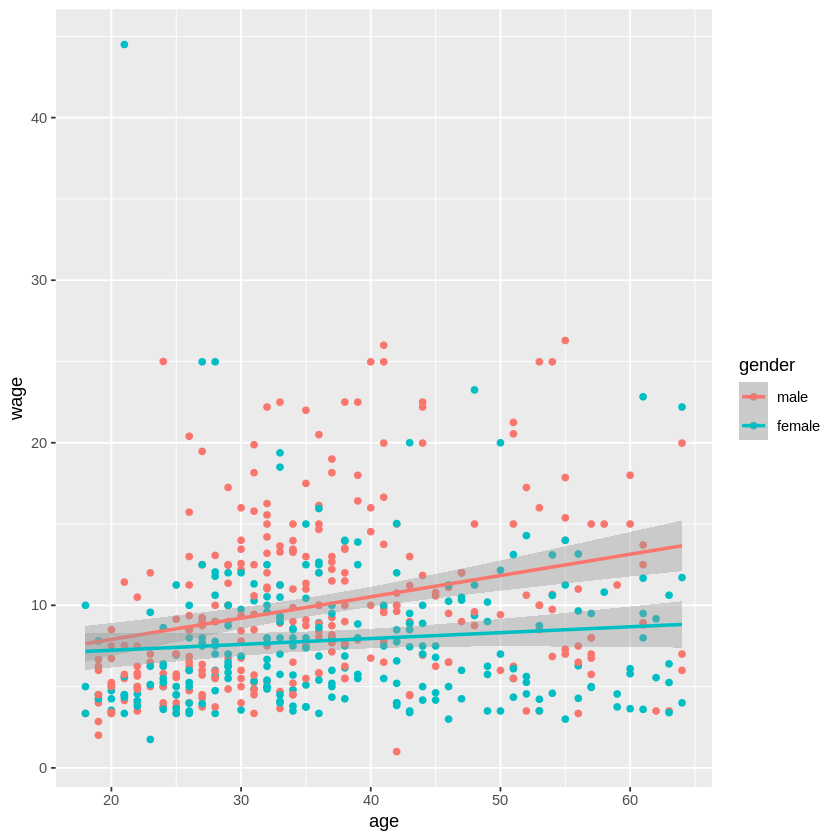

In [21]:
ggplot(data = CPS1985, aes(x = age, y = wage, color = gender)) +
  geom_point() +
  geom_smooth(method="lm", se=T)

Putting only the term `age*gender` would come in handy especially for three (or more!) way interactions, in which case spelling out every constituent term would be cumbersome:

In [22]:
summary(lm(wage ~ age*gender*married, data = CPS1985))


Call:
lm(formula = wage ~ age * gender * married, data = CPS1985)

Residuals:
    Min      1Q  Median      3Q     Max 
-10.694  -3.312  -1.132   2.298  36.680 

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  3.13222    1.61582   1.938 0.053100 .  
age                          0.17559    0.05181   3.389 0.000753 ***
genderfemale                 4.05017    2.23189   1.815 0.070143 .  
marriedyes                   4.65640    2.08883   2.229 0.026223 *  
age:genderfemale            -0.14522    0.06587  -2.205 0.027914 *  
age:marriedyes              -0.09709    0.06111  -1.589 0.112716    
genderfemale:marriedyes     -5.99754    2.95054  -2.033 0.042585 *  
age:genderfemale:marriedyes  0.11390    0.08115   1.403 0.161067    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.889 on 526 degrees of freedom
Multiple R-squared:  0.1067,	Adjusted R-squared:  0.09483 
F-statistic: 8.977 

We can also visualize a three-way interaction

`geom_smooth()` using formula = 'y ~ x'


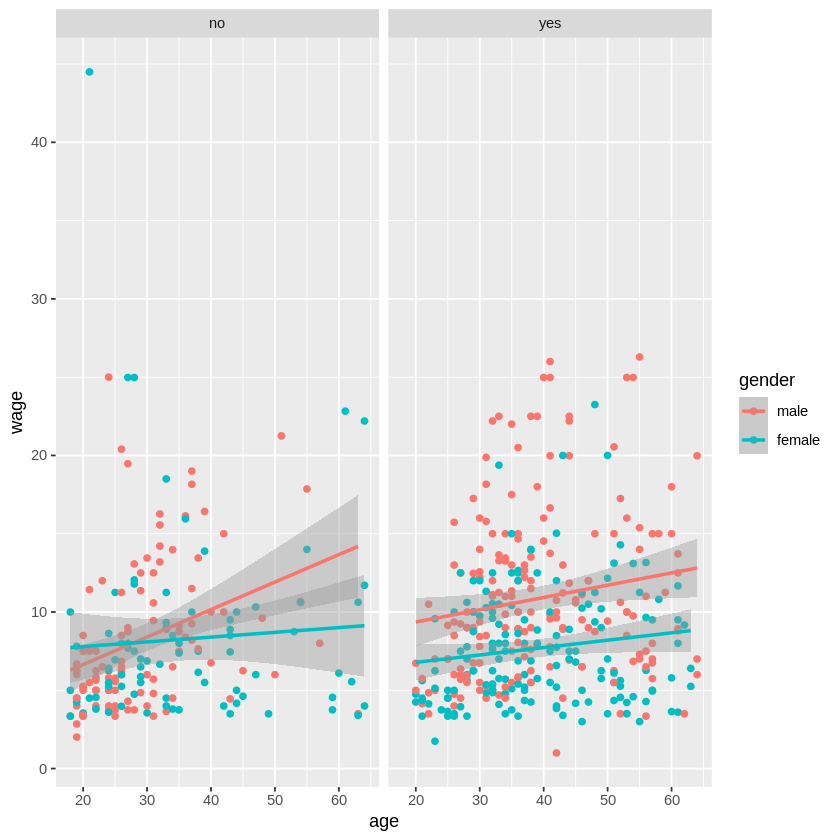

In [23]:
ggplot(CPS1985, aes(x = age, y = wage, color = gender, group = gender)) +
    geom_point() +
    geom_smooth(method="lm", se=T)+
    facet_grid(. ~ married)

## Stargazer

After we run a regression, we usually want to present them in a publication, paper, poster, website, etc. in a visually appealing way.
A great package to help with creating such tables is `stargazer`.
The main function to create well-formatted tables in stargazer is also called `stargazer()`.

(To be able to use `stargazer`, you should have installed and loaded the package using the code chunk at the beginning of this notebook. Please do that before proceeding if you have not.)

Stargazer can handle different combinations of independent variables for the same dependent variable, for different dependent variables, column labels, and comes with many more options. It can produce LaTeX code, HTML code, or ASCII text. We'll use the last one for demonstration purposes.


Let's fit a few different models for the `wage` outcome variable in `CPS1985`.
Note that these aren't wrapped in summary(); we just store each model object.

In [24]:
m1 <- lm(wage ~ education, data = CPS1985)
m2 <- lm(wage ~ education + age + gender, data = CPS1985)
m3 <- lm(wage ~ education + age + gender + age*gender, data = CPS1985)

In [25]:
stargazer(m1, m2, m3, type = 'text')


                                              Dependent variable:                          
                    -----------------------------------------------------------------------
                                                     wage                                  
                              (1)                     (2)                     (3)          
-------------------------------------------------------------------------------------------
education                  0.750***                0.827***                0.827***        
                            (0.079)                 (0.075)                 (0.074)        
                                                                                           
age                                                0.113***                0.158***        
                                                    (0.017)                 (0.023)        
                                                                               

The output is already pretty nice, but we might want to edit the variable names a bit.
Let's capitalize first letters, rename "genderfemale" as "Female", and indicate interaction with a `*` rather than `:`.

In [26]:
stargazer(m1, m2, m3, type = 'text',
          covariate.labels = c('Education', 'Age', 'Female' , 'Age*Female'),
          dep.var.labels = 'Wage')


                                              Dependent variable:                          
                    -----------------------------------------------------------------------
                                                     Wage                                  
                              (1)                     (2)                     (3)          
-------------------------------------------------------------------------------------------
Education                  0.750***                0.827***                0.827***        
                            (0.079)                 (0.075)                 (0.074)        
                                                                                           
Age                                                0.113***                0.158***        
                                                    (0.017)                 (0.023)        
                                                                               

Some people hate the stars next to the coefficient values for understandable reasons.
The thresholds (significance levels) that decide whether a p-value is ``significant'' or not are arbitrary.
They also incentivize p-hacking.
Despite its name, stargazer will allow you to remove the stars if desired.

In [27]:
stargazer(m1, m2, m3, type = 'text',
          covariate.labels = c('Education', 'Age', 'Female' , 'Age*Female'),
          dep.var.labels = 'Wage',
          star.cutoffs = NA)


                                         Dependent variable:                      
                    --------------------------------------------------------------
                                                 Wage                             
                            (1)                  (2)                  (3)         
----------------------------------------------------------------------------------
Education                  0.750                0.827                0.827        
                          (0.079)              (0.075)              (0.074)       
                                                                                  
Age                                             0.113                0.158        
                                               (0.017)              (0.023)       
                                                                                  
Female                                          -2.335               1.137        
   

`stargazer` has many many more options that allow you to control what is displayed in the output and what format it is produced in.